<a href="https://colab.research.google.com/github/Andalejo1109/portafolio-10k-3y/blob/main/Portafolio_10k_3y.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance pandas matplotlib pillow

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.ticker as mtick

In [12]:
# --- 1. Parámetros de la simulación ---
pago_mensual = 200
meses_simulacion = 36
ticker = "SPYG" # Puedes cambiarlo a "SMH", "VTI", "IEMG", etc.

print(f"Descargando datos históricos de {ticker}...")

# --- 2. Descargar datos históricos del ETF ---
# Usamos yf.Ticker para obtener el precio de cierre ajustado directamente
etf = yf.Ticker(ticker)
df = etf.history(period="5y", interval="1mo")

# Calcular los retornos mensuales y tomar los últimos 36 meses disponibles
retornos_mensuales = df['Close'].pct_change().dropna()
retornos_36m = retornos_mensuales.tail(meses_simulacion)
retornos_36m

Descargando datos históricos de SPYG...


,Close
Date,
2023-09-01 00:00:00-04:00,-0.048748
2023-10-01 00:00:00-04:00,-0.024291
2023-11-01 00:00:00-04:00,0.087310
2023-12-01 00:00:00-05:00,0.037804
2024-01-01 00:00:00-05:00,0.028743
2024-02-01 00:00:00-05:00,0.071866
2024-03-01 00:00:00-05:00,0.021165
2024-04-01 00:00:00-04:00,-0.038688
2024-05-01 00:00:00-04:00,0.066695


In [17]:
# --- 3. Simulación del Portafolio ---
fechas = retornos_36m.index
aportes_totales = []
valores_portafolio = []

valor_actual = 0
aporte_acumulado = 0

for retorno in retornos_36m:
    aporte_acumulado += pago_mensual
    # Se suma el aporte y se multiplica por el rendimiento real de ese mes
    valor_actual = (valor_actual + pago_mensual) * (1 + float(retorno))

    aportes_totales.append(aporte_acumulado)
    valores_portafolio.append(valor_actual)



¡Listo! Gráfico guardado como 'grafica_estatica_SPYG.png' en tu carpeta actual.


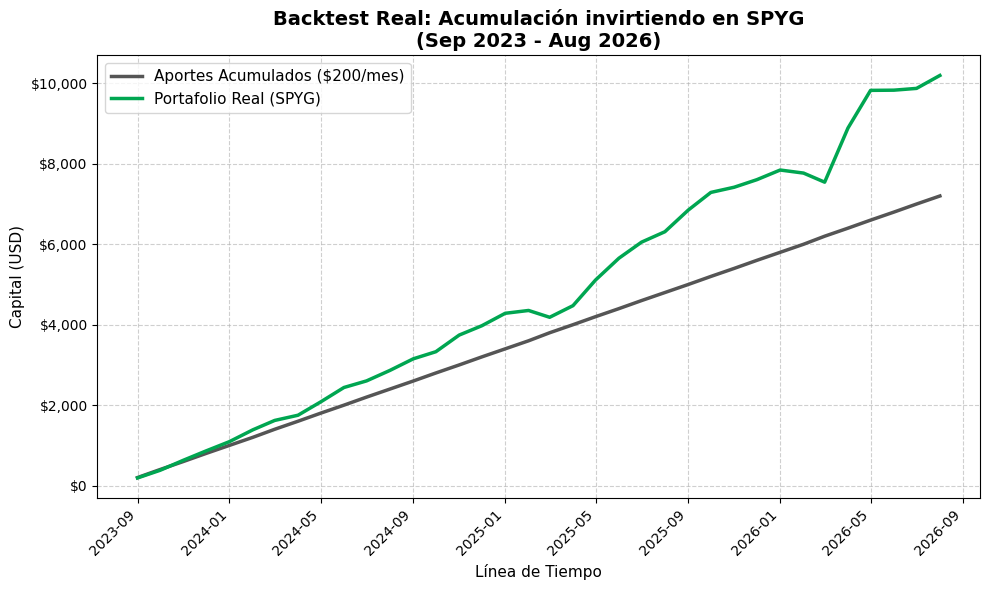

In [18]:
# --- 6. Configuración y Generación del Gráfico Estático ---
fig, ax = plt.subplots(figsize=(10, 6))

# Trazar las dos líneas
ax.plot(fechas, aportes_totales, color='#555555', linewidth=2.5,
label=f'Aportes Acumulados (${pago_mensual}/mes)')
ax.plot(fechas, valores_portafolio, color='#00a651', linewidth=2.5,
label=f'Portafolio Real ({ticker})')

# Formatear el eje Y como dólares ($X,XXX)
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

# Títulos
fecha_inicial = fechas[0].strftime('%b %Y')
fecha_final = fechas[-1].strftime('%b %Y')
ax.set_title(f"Backtest Real: Acumulación invirtiendo en {ticker}\n({fecha_inicial} - {fecha_final})",
fontsize=14, fontweight='bold')
ax.set_xlabel("Línea de Tiempo", fontsize=11)
ax.set_ylabel("Capital (USD)", fontsize=11)

# Estética adicional
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()

# --- 7. Guardar la imagen ---
nombre_imagen = f"grafica_estatica_{ticker}.png"
plt.savefig(nombre_imagen, dpi=300) # dpi=300 asegura calidad de impresión/HD
print(f"¡Listo! Gráfico guardado como '{nombre_imagen}' en tu carpeta actual.")

¡Listo! Archivo guardado como '10k_real3y'


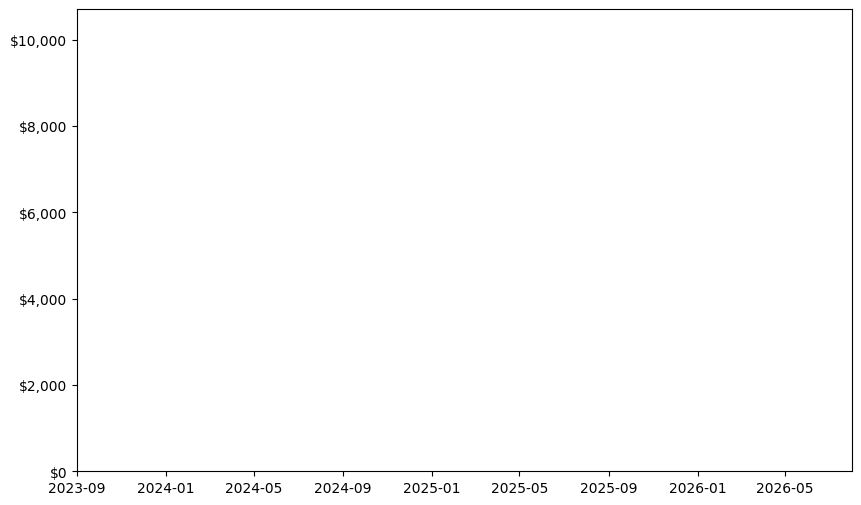

In [27]:
# --- 4. Configuración del Gráfico Animado ---
fig, ax = plt.subplots(figsize=(10, 6))

# Fijar límites de los ejes para que la gráfica no "salte" en la animación
ax.set_xlim(fechas[0], fechas[-1])
limite_y = max(valores_portafolio) * 1.05
ax.set_ylim(0, limite_y)

# Formatear el eje Y como dólares
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

def update(frame):
    ax.clear()

    # Mantener los límites fijos en cada frame
    ax.set_xlim(fechas[0], fechas[-1])
    ax.set_ylim(0, limite_y)
    ax.yaxis.set_major_formatter(tick)

    # Graficar los datos hasta el 'frame' actual
    fechas_frame = fechas[:frame+1]
    aportes_frame = aportes_totales[:frame+1]
    valores_frame = valores_portafolio[:frame+1]

    ax.plot(fechas_frame, aportes_frame, color='#555555', linewidth=2.5,
    label=f'Aportes Acumulados (${pago_mensual}/mes)')
    ax.plot(fechas_frame, valores_frame, color='#00a651', linewidth=2.5,
    label=f'Portafolio Real ({ticker})')

    # Títulos y etiquetas dinámicas
    fecha_actual = fechas_frame[-1].strftime('%b %Y')
    ax.set_title(f"Backtest Real: Acumulación invirtiendo en {ticker}\nFecha: {fecha_actual}",
    fontsize=14, fontweight='bold')

    ax.set_xlabel("Línea de Tiempo", fontsize=11)
    ax.set_ylabel("Capital (USD)", fontsize=11)

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', fontsize=11)

    # Rotar las fechas para mejor legibilidad
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # --- 5. Renderizar y Guardar ---
    print("Generando animación, esto puede tomar unos segundos...")

    # Creamos la animación (frames = cantidad de meses)
    ani = FuncAnimation(fig, update, frames=len(fechas), interval=150, repeat=False)

    # Guardar como GIF en el mismo directorio donde se ejecuta el script
    nombre_archivo = f"simulacion_real_{ticker}.gif"
    ani.save(nombre_archivo, writer=PillowWriter(fps=8))

print(f"¡Listo! Archivo guardado como '{"10k_real3y"}'")

In [25]:
from google.colab import files

files.download("10k_real3y")

FileNotFoundError: Cannot find file: 10k_real3y